CÀI GÓI & CẤU HÌNH

In [2]:
# !pip install torch torchvision numpy opencv-python pillow matplotlib scikit-learn tqdm
import os, json, math, random, cv2, numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if DEVICE == "cuda":
    gpu_name = torch.cuda.get_device_name(0)
    print(f"⚙️ Using GPU: {gpu_name}")
else:
    print("⚙️ Using CPU")

DATA_ROOT = r"E:\data_train\data_train"   # <= sửa về thư mục có train/val/test
IMG_SIZE = 384
BATCH_SIZE = 16
LR = 1e-4
EPOCHS = 8
OUT_DIR = "./outputs_cls_cam"
os.makedirs(OUT_DIR, exist_ok=True)


⚙️ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


ĐỌC DỮ LIỆU & THỐNG KÊ CÂN BẰNG LỚP

In [3]:
# Dùng ImageFolder vì bạn đã tổ chức theo thư mục lớp
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomApply([transforms.ColorJitter(0.08,0.08,0.08,0.02)], p=0.7),
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, "val"),   transform=eval_tf)
test_ds  = datasets.ImageFolder(os.path.join(DATA_ROOT, "test"),  transform=eval_tf)

idx_to_class = {v:k for k,v in train_ds.class_to_idx.items()}
with open(os.path.join(OUT_DIR, "idx_to_class.json"), "w", encoding="utf-8") as f:
    json.dump(idx_to_class, f, ensure_ascii=False, indent=2)

def class_counts(ds):
    counts = {idx_to_class[i]:0 for i in range(len(idx_to_class))}
    for _, y in ds.samples:
        counts[idx_to_class[y]] += 1
    return counts

train_counts = class_counts(train_ds)
val_counts   = class_counts(val_ds)
test_counts  = class_counts(test_ds)
train_counts, val_counts, test_counts


({'crease': 1184,
  'crescent_gap': 1138,
  'inclusion': 1144,
  'oil_spot': 1132,
  'punching_hole': 1134,
  'rolled_pit': 1190,
  'silk_spot': 1004,
  'waist_folding': 1156,
  'water_spot': 1112,
  'welding_line': 1112},
 {'crease': 15,
  'crescent_gap': 31,
  'inclusion': 28,
  'oil_spot': 34,
  'punching_hole': 33,
  'rolled_pit': 15,
  'silk_spot': 98,
  'waist_folding': 22,
  'water_spot': 44,
  'welding_line': 44},
 {'crease': 22,
  'crescent_gap': 31,
  'inclusion': 28,
  'oil_spot': 34,
  'punching_hole': 33,
  'rolled_pit': 25,
  'silk_spot': 98,
  'waist_folding': 22,
  'water_spot': 44,
  'welding_line': 44})

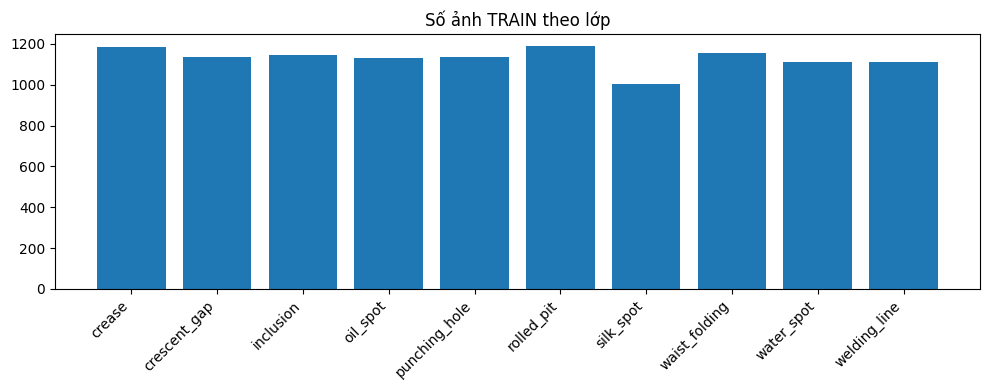

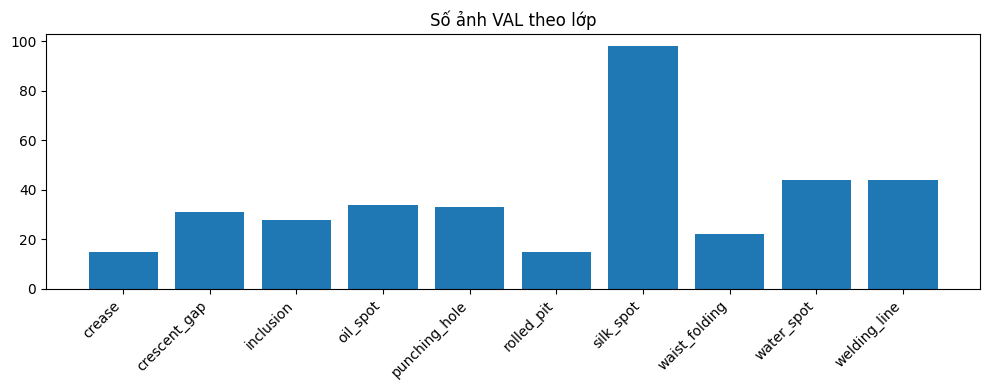

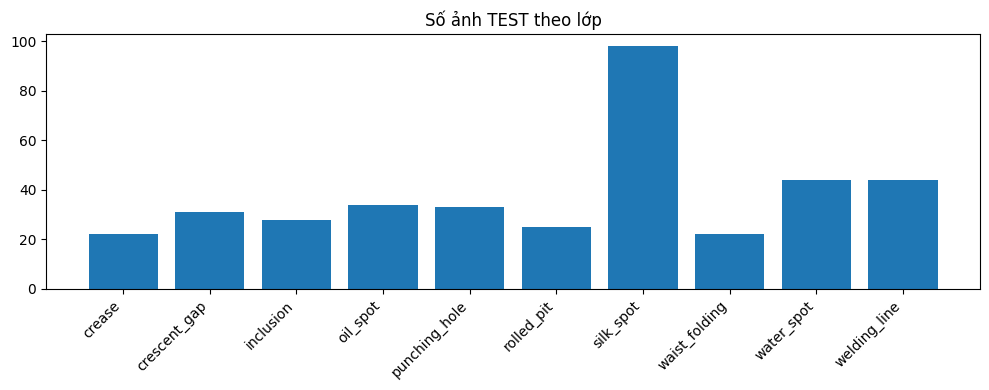

In [4]:
# Vẽ biểu đồ số ảnh mỗi lớp (train/val/test)
def plot_counts(counts, title):
    names = list(counts.keys())
    vals = [counts[k] for k in names]
    plt.figure(figsize=(10,4))
    plt.bar(names, vals)            # không set màu theo yêu cầu tool
    plt.xticks(rotation=45, ha='right')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_counts(train_counts, "Số ảnh TRAIN theo lớp")
plot_counts(val_counts,   "Số ảnh VAL theo lớp")
plot_counts(test_counts,  "Số ảnh TEST theo lớp")


DATALOADER

In [5]:
# Tạo sampler có trọng số để giảm lệch lớp (tuỳ chọn)
use_weighted_sampler = True
if use_weighted_sampler:
    class_sample_count = np.array([train_counts[idx_to_class[i]] for i in range(len(idx_to_class))])
    weights = 1.0 / np.maximum(class_sample_count, 1)
    sample_weights = [weights[y] for _, y in train_ds.samples]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

val_loader  = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


In [ ]:
MÔ HÌNH BASELINE (RESNET50) & HUẤN LUYỆN

Epoch |        LR |  TrainLoss |  ValLoss | TrainAcc |   ValAcc
-----------------------------------------------------------------


Epoch 1/8: 100%|████████████████████████████████████████████| 707/707 [44:28<00:00,  3.77s/it, acc=0.8194, loss=0.2424]


    1 |  0.000096 |     0.5955 |   0.1868 |   0.8194 |   0.9313
  -> saved best: ./outputs_cls_cam\resnet50_cls.pth (val_acc=0.9313)


Epoch 2/8: 100%|████████████████████████████████████████████| 707/707 [48:00<00:00,  4.07s/it, acc=0.9333, loss=0.0616]


    2 |  0.000085 |     0.2081 |   0.1566 |   0.9333 |   0.9588
  -> saved best: ./outputs_cls_cam\resnet50_cls.pth (val_acc=0.9588)


...

    6 |  0.000015 |     0.0417 |   0.0706 |   0.9874 |   0.9835
  -> saved best: ./outputs_cls_cam\resnet50_cls.pth (val_acc=0.9835)


Epoch 7/8: 100%|████████████████████████████████████████████| 707/707 [39:42<00:00,  3.37s/it, acc=0.9929, loss=0.0035]


    7 |  0.000004 |     0.0246 |   0.0738 |   0.9929 |   0.9780


Epoch 8/8: 100%|████████████████████████████████████████████| 707/707 [46:26<00:00,  3.94s/it, acc=0.9926, loss=0.0025]


    8 |  0.000000 |     0.0230 |   0.0656 |   0.9926 |   0.9808


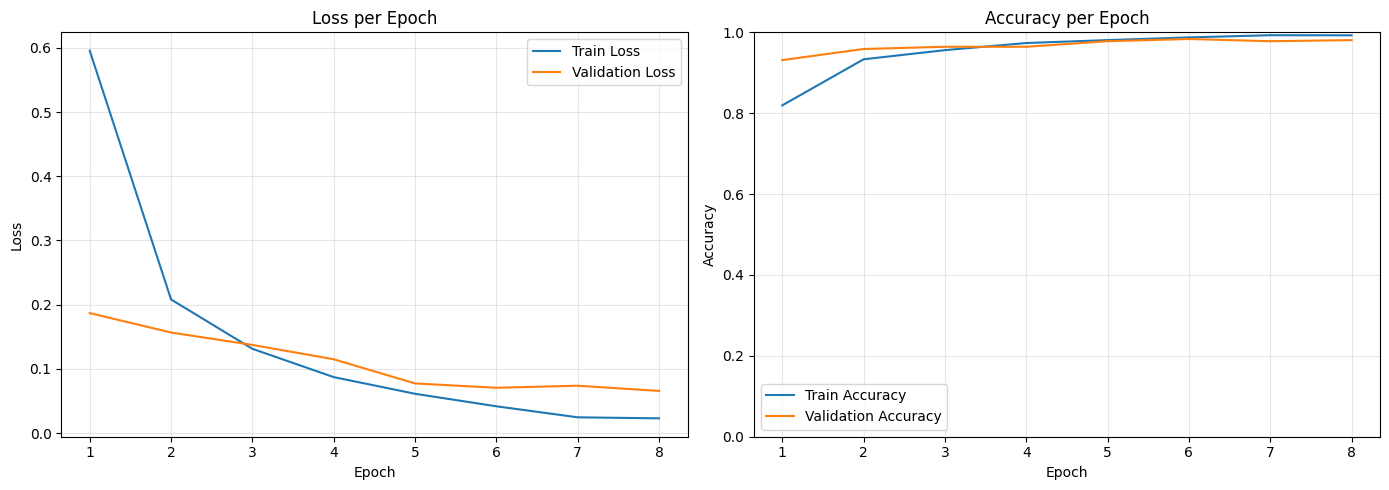

C:\Users\MINH\AppData\Local\Temp\ipykernel_22480\2211404852.py:111: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(best_path, map_location=DEVICE)


KeyError: '0'

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import itertools
def build_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_feats = m.fc.in_features
    m.fc = nn.Linear(in_feats, num_classes)
    return m
def evaluate(model, loader):
    model.eval()
    ce = nn.CrossEntropyLoss()
    total, correct, loss_sum = 0, 0, 0.0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = ce(logits, y)
            loss_sum += loss.item()*x.size(0)
            pred = logits.argmax(1)
            correct += (pred==y).sum().item()
            total += x.size(0)
    return correct/total, loss_sum/total

# ----- build model / optimizer / scheduler như bạn đã có -----
num_classes = len(idx_to_class)
model = build_model(num_classes).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

best_acc = 0.0
best_path = os.path.join(OUT_DIR, "resnet50_cls.pth")

# lưu lịch sử để vẽ
hist = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
    "lr": []
}

print(f"{'Epoch':>5} | {'LR':>9} | {'TrainLoss':>10} | {'ValLoss':>8} | {'TrainAcc':>8} | {'ValAcc':>8}")
print("-"*65)

for ep in range(1, EPOCHS+1):
    model.train()
    running_correct, running_total, running_loss = 0, 0, 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}")
    for x,y in pbar:
        x,y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = F.cross_entropy(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        with torch.no_grad():
            pred = logits.argmax(1)
            running_correct += (pred==y).sum().item()
            running_total   += y.size(0)
            running_loss    += loss.item() * y.size(0)
            train_acc_now    = running_correct / max(1, running_total)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{train_acc_now:.4f}")

    sched.step()

    # tổng kết epoch
    train_acc  = running_correct / max(1, running_total)
    train_loss = running_loss  / max(1, running_total)

    val_acc, val_loss = evaluate(model, val_loader)

    # lưu lịch sử & in ra 1 dòng
    lr_now = opt.param_groups[0]['lr']
    hist["train_loss"].append(train_loss)
    hist["val_loss"].append(val_loss)
    hist["train_acc"].append(train_acc)
    hist["val_acc"].append(val_acc)
    hist["lr"].append(lr_now)

    print(f"{ep:5d} | {lr_now:9.6f} | {train_loss:10.4f} | {val_loss:8.4f} | {train_acc:8.4f} | {val_acc:8.4f}")

    # save best
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({"model": model.state_dict()}, best_path)
        print(f"  -> saved best: {best_path} (val_acc={best_acc:.4f})")

# ===== Vẽ biểu đồ Loss & Accuracy =====
epochs = np.arange(1, len(hist["train_loss"])+1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, hist["train_loss"], label="Train Loss")
plt.plot(epochs, hist["val_loss"],   label="Validation Loss")
plt.title("Loss per Epoch"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(epochs, hist["train_acc"], label="Train Accuracy")
plt.plot(epochs, hist["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy per Epoch"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.ylim(0,1.0); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# ===== Đánh giá trên TEST: Confusion Matrix + report =====
# load best
ckpt = torch.load(best_path, map_location=DEVICE)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state)
model.eval()

# gom nhãn thật / dự đoán
y_true, y_pred = [], []
with torch.no_grad():
    for x,y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        y_pred.extend(logits.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
labels = [idx_to_class[str(i)] for i in range(num_classes)]

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(
    xticks=np.arange(cm.shape[1]),
    yticks=np.arange(cm.shape[0]),
    xticklabels=labels, yticklabels=labels,
    ylabel='True label', xlabel='Predicted label',
    title='Confusion Matrix (TEST)'
)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# ghi số lên từng ô
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, format(cm[i, j], 'd'),
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black")
plt.tight_layout(); plt.show()

# Classification report (tùy thích in thêm)
print(classification_report(y_true, y_pred, target_names=labels, digits=4))


ĐÁNH GIÁ CHI TIẾT (CONFUSION MATRIX, CLASSIFICATION REPORT)

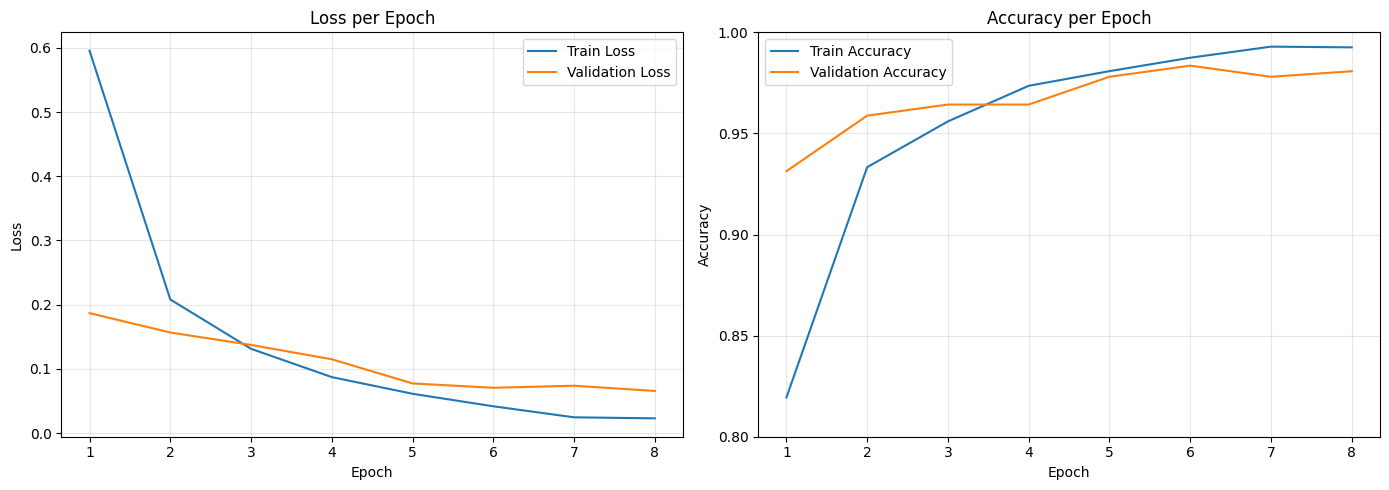

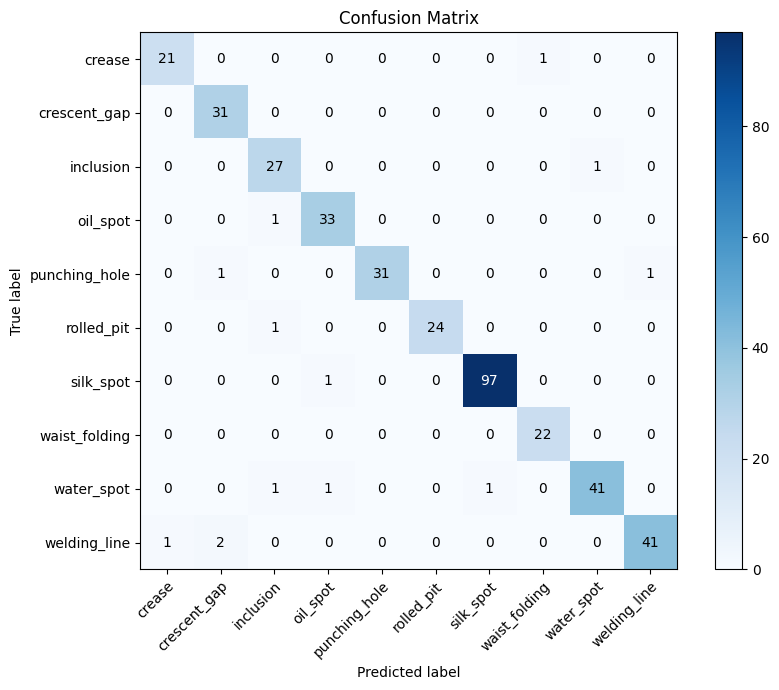

               precision    recall  f1-score   support

       crease     0.9545    0.9545    0.9545        22
 crescent_gap     0.9118    1.0000    0.9538        31
    inclusion     0.9000    0.9643    0.9310        28
     oil_spot     0.9429    0.9706    0.9565        34
punching_hole     1.0000    0.9394    0.9688        33
   rolled_pit     1.0000    0.9600    0.9796        25
    silk_spot     0.9898    0.9898    0.9898        98
waist_folding     0.9565    1.0000    0.9778        22
   water_spot     0.9762    0.9318    0.9535        44
 welding_line     0.9762    0.9318    0.9535        44

     accuracy                         0.9659       381
    macro avg     0.9608    0.9642    0.9619       381
 weighted avg     0.9671    0.9659    0.9660       381



In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# --- Biểu đồ Loss & Accuracy ---
epochs = np.arange(1, len(hist["train_loss"])+1)

plt.figure(figsize=(14,5))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs, hist["train_loss"], label="Train Loss")
plt.plot(epochs, hist["val_loss"],   label="Validation Loss")
plt.title("Loss per Epoch"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(True, alpha=0.3)

# Accuracy (zoom 0.8–1.0)
plt.subplot(1,2,2)
plt.plot(epochs, hist["train_acc"], label="Train Accuracy")
plt.plot(epochs, hist["val_acc"],   label="Validation Accuracy")
plt.title("Accuracy per Epoch"); plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.ylim(0.80, 1.00)     # zoom
plt.yticks([0.80,0.85,0.90,0.95,1.00])
plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# --- Đánh giá trên TEST: Confusion Matrix ---
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state)
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(1).cpu().tolist()  # dự đoán top-1 cho batch
        y_pred.extend(preds)                     # thêm vào list
        y_true.extend(y.tolist())                # nhãn thật

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# lấy labels từ idx_to_class (key int hoặc str đều được)
if 0 in idx_to_class:
    labels = [idx_to_class[i] for i in range(num_classes)]
elif "0" in idx_to_class:
    labels = [idx_to_class[str(i)] for i in range(num_classes)]
else:
    labels = list(range(num_classes))

# Tạo confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

# Vẽ ma trận
fig, ax = plt.subplots(figsize=(9,7))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

ax.set(
    xticks=np.arange(num_classes),
    yticks=np.arange(num_classes),
    xticklabels=labels, yticklabels=labels,
    ylabel='True label',
    xlabel='Predicted label',
    title='Confusion Matrix'
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

# Ghi số lên từng ô
thresh = cm.max() / 2.0 if cm.size > 0 else 0
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, int(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

# In thêm classification report
print(classification_report(y_true, y_pred, target_names=labels, digits=4))


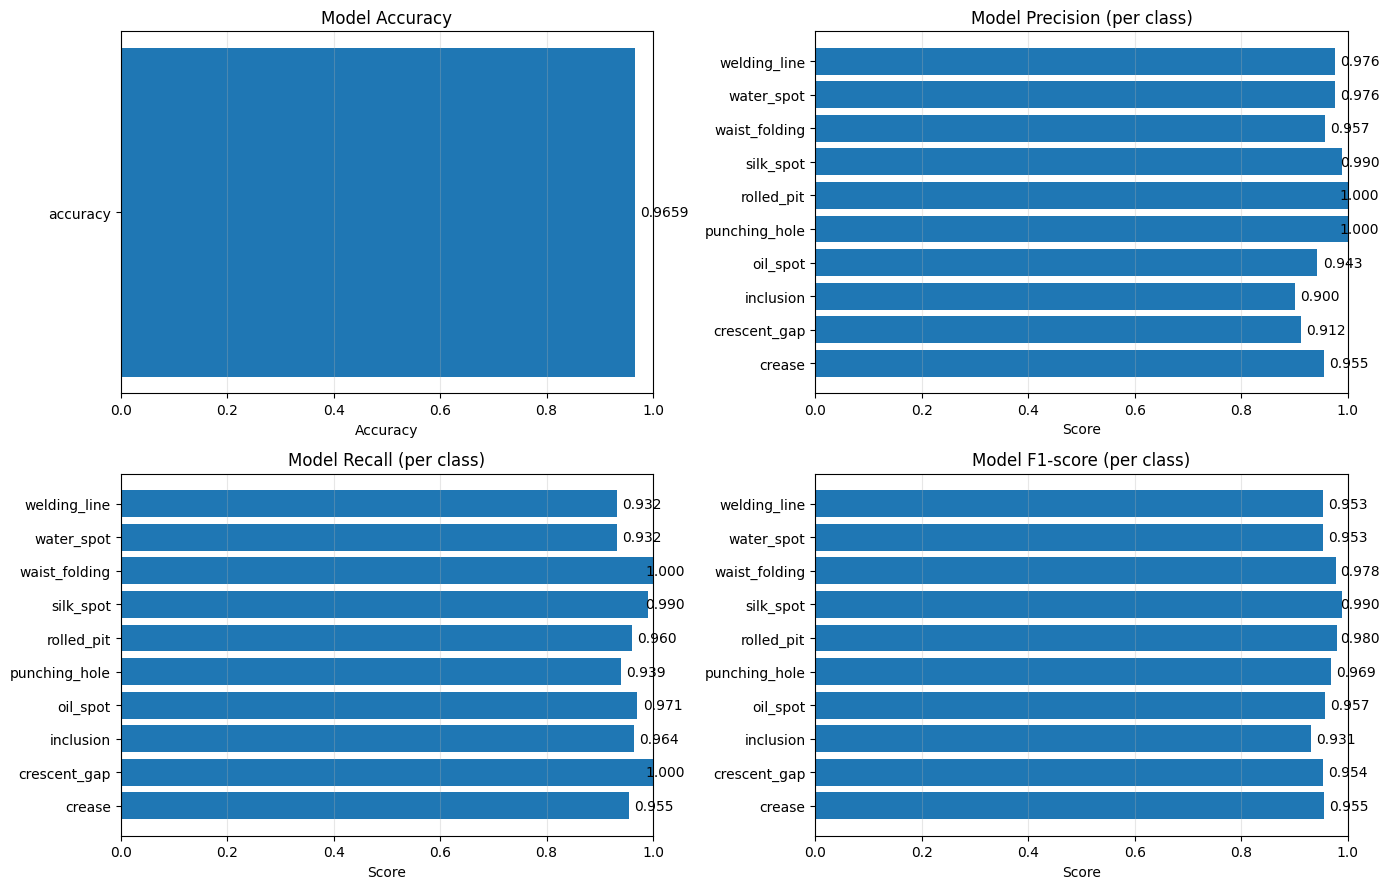

In [7]:
# ==== 2x2 SUBPLOTS: Overall Accuracy + Precision/Recall/F1 per class (10 lỗi) ====
import os, torch, torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torchvision import models

# ---------- CONFIG ----------
best_path = os.path.join(OUT_DIR, "resnet50_cls.pth")
num_classes = len(idx_to_class)

def build_model(num_classes):
    m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    in_feats = m.fc.in_features
    m.fc = nn.Linear(in_feats, num_classes)
    return m

# ---------- Load model ----------
model = build_model(num_classes).to(DEVICE)
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=True)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
# gỡ 'module.' nếu có
if len(state) > 0 and next(iter(state.keys())).startswith("module."):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}
model.load_state_dict(state, strict=False)
model.eval()

# ---------- Predict on TEST ----------
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        y_pred.extend(logits.argmax(1).cpu().tolist())
        y_true.extend(y.tolist())

# ---------- Labels (tên lớp) ----------
if all(isinstance(k, int) for k in idx_to_class.keys()):      # {int: str}
    labels = [idx_to_class[i] for i in range(num_classes)]
else:                                                          # {str: int} -> invert
    inv = {v: k for k, v in idx_to_class.items()}
    labels = [inv[i] for i in range(num_classes)]

# ---------- Metrics per class ----------
rep = classification_report(y_true, y_pred, target_names=labels, digits=4, output_dict=True)
precision = np.array([rep[c]["precision"] for c in labels])
recall    = np.array([rep[c]["recall"]    for c in labels])
f1        = np.array([rep[c]["f1-score"]  for c in labels])
overall_acc = float(rep["accuracy"])

# ---------- VẼ 2×2 ----------
fig = plt.figure(figsize=(14, 9))

# (1) Overall Accuracy (single bar ngang cho hợp layout)
ax1 = plt.subplot(2, 2, 1)
ax1.barh(["accuracy"], [overall_acc])
ax1.set_xlim(0, 1.0)
ax1.set_title("Model Accuracy")
ax1.set_xlabel("Accuracy")
for i, v in enumerate([overall_acc]):
    ax1.text(v + 0.01, i, f"{v:.4f}", va="center")
ax1.grid(True, axis="x", alpha=0.3)

# Helper: vẽ barh có nhãn giá trị
def barh_with_values(ax, ylabels, vals, title):
    y_pos = np.arange(len(ylabels))
    ax.barh(y_pos, vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(ylabels)
    ax.set_xlim(0, 1.0)
    ax.set_title(title)
    ax.set_xlabel("Score")
    for i, v in enumerate(vals):
        ax.text(min(v + 0.01, 0.985), i, f"{v:.3f}", va="center")
    ax.grid(True, axis="x", alpha=0.3)

# (2) Precision per class
ax2 = plt.subplot(2, 2, 2)
barh_with_values(ax2, labels, precision, "Model Precision (per class)")

# (3) Recall per class
ax3 = plt.subplot(2, 2, 3)
barh_with_values(ax3, labels, recall, "Model Recall (per class)")

# (4) F1-score per class
ax4 = plt.subplot(2, 2, 4)
barh_with_values(ax4, labels, f1, "Model F1-score (per class)")

plt.tight_layout()
plt.show()


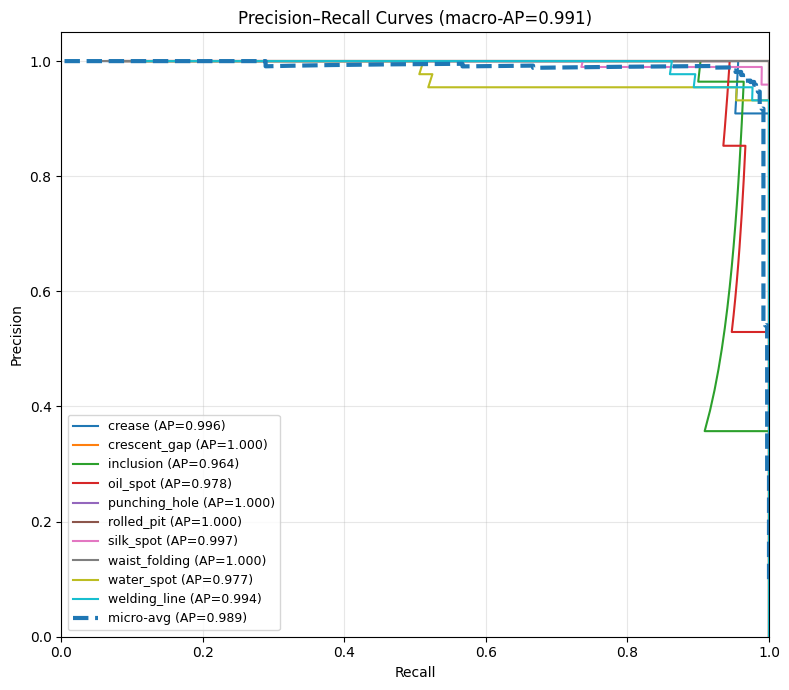

In [14]:
# ===== Cell: Precision–Recall curves (per-class + micro) =====
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1) Load best weights (nếu chưa)
ckpt = torch.load(best_path, map_location=DEVICE, weights_only=False)
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state)
model.eval()

# 2) Thu thập y_true (int) và y_score (softmax prob, shape [N, C])
y_true = []
y_score_list = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        logits = model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        y_score_list.append(probs)
        y_true.extend(y.cpu().numpy().tolist())

y_true = np.array(y_true)                     # shape [N]
y_score = np.concatenate(y_score_list, axis=0)  # shape [N, C]
assert y_score.shape[1] == num_classes

# 3) Nhãn hiển thị (hỗ trợ idx_to_class key int/str)
if isinstance(idx_to_class, dict):
    if 0 in idx_to_class:
        class_names = [idx_to_class[i] for i in range(num_classes)]
    elif "0" in idx_to_class:
        class_names = [idx_to_class[str(i)] for i in range(num_classes)]
    else:
        class_names = [str(i) for i in range(num_classes)]
elif isinstance(idx_to_class, (list, tuple)):
    class_names = list(idx_to_class)
else:
    class_names = [str(i) for i in range(num_classes)]

# 4) Binarize nhãn thật để tính PR theo lớp
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))  # shape [N, C]

# 5) Tính PR curve & AP cho từng lớp + micro-average
precisions = {}
recalls    = {}
APs        = {}

for c in range(num_classes):
    r, p, _ = precision_recall_curve(y_true_bin[:, c], y_score[:, c])
    # sklearn trả về (precision, recall, thresholds) nhưng một số phiên bản là (precision, recall, thresholds)
    # Đảm bảo thứ tự đúng: precision_recall_curve -> (precision, recall, thresholds)
    # Ở đây đặt tên r,p theo recall,precision cho dễ đọc khi plot
    precisions[c] = p
    recalls[c]    = r
    APs[c]        = average_precision_score(y_true_bin[:, c], y_score[:, c])

# micro-average
p_micro, r_micro, _ = precision_recall_curve(y_true_bin.ravel(), y_score.ravel())
AP_micro = average_precision_score(y_true_bin, y_score, average="micro")
AP_macro = average_precision_score(y_true_bin, y_score, average="macro")

# 6) Vẽ PR Curves
plt.figure(figsize=(8,7))

# Vẽ từng lớp
for c in range(num_classes):
    plt.plot(recalls[c], precisions[c], linewidth=1.5, label=f"{class_names[c]} (AP={APs[c]:.3f})")

# Vẽ micro-average dày hơn
plt.plot(r_micro, p_micro, linewidth=3, linestyle="--", label=f"micro-avg (AP={AP_micro:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curves (macro-AP={AP_macro:.3f})")
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left", ncol=1, fontsize=9)
plt.tight_layout()
plt.show()


In [ ]:
# def build_model(num_classes):
#     m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
#     in_feats = m.fc.in_features
#     m.fc = nn.Linear(in_feats, num_classes)
#     return m

# def evaluate(model, loader):
#     model.eval()
#     ce = nn.CrossEntropyLoss()
#     total, correct, loss_sum = 0, 0, 0.0
#     with torch.no_grad():
#         for x,y in loader:
#             x,y = x.to(DEVICE), y.to(DEVICE)
#             logits = model(x)
#             loss = ce(logits, y)
#             loss_sum += loss.item()*x.size(0)
#             pred = logits.argmax(1)
#             correct += (pred==y).sum().item()
#             total += x.size(0)
#     return correct/total, loss_sum/total

# num_classes = len(idx_to_class)
# model = build_model(num_classes).to(DEVICE)
# opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

# best_acc, best_path = 0.0, os.path.join(OUT_DIR, "resnet50_cls.pth")

# for ep in range(1, EPOCHS+1):
#     model.train()
#     running_correct, running_total, running_loss = 0, 0, 0.0

#     pbar = tqdm(train_loader, desc=f"Epoch {ep}/{EPOCHS}")
#     for x,y in pbar:
#         x,y = x.to(DEVICE), y.to(DEVICE)
#         logits = model(x)
#         loss = F.cross_entropy(logits, y)

#         opt.zero_grad()
#         loss.backward()
#         opt.step()

#         # cập nhật thống kê train
#         with torch.no_grad():
#             pred = logits.argmax(1)
#             running_correct += (pred==y).sum().item()
#             running_total   += y.size(0)
#             running_loss    += loss.item() * y.size(0)
#             train_acc_now    = running_correct / max(1, running_total)

#         pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{train_acc_now:.4f}")

#     sched.step()

#     # tổng kết epoch
#     train_acc = running_correct / max(1, running_total)
#     train_loss = running_loss / max(1, running_total)
#     print(f"[Train] acc={train_acc:.4f} loss={train_loss:.4f}")

#     # validation
#     val_acc, val_loss = evaluate(model, val_loader)
#     print(f"[Val]   acc={val_acc:.4f} loss={val_loss:.4f}")

#     if val_acc > best_acc:
#         best_acc = val_acc
#         torch.save({"model": model.state_dict()}, best_path)
#         print(f"  -> saved best: {best_path} (val_acc={best_acc:.4f})")

Epoch 1/8: 100%|████████████████████████████████████████████| 707/707 [38:39<00:00,  3.28s/it, acc=0.8134, loss=0.3478]


[Train] acc=0.8134 loss=0.6041
[Val]   acc=0.9396 loss=0.1716
  -> saved best: ./outputs_cls_cam\resnet50_cls.pth (val_acc=0.9396)


Epoch 2/8: 100%|████████████████████████████████████████████| 707/707 [39:28<00:00,  3.35s/it, acc=0.9283, loss=0.0450]


[Train] acc=0.9283 loss=0.2168
[Val]   acc=0.9396 loss=0.1895


Epoch 3/8: 100%|████████████████████████████████████████████| 707/707 [38:49<00:00,  3.30s/it, acc=0.9567, loss=0.0146]


...

Epoch 5/8: 100%|████████████████████████████████████████████| 707/707 [47:23<00:00,  4.02s/it, acc=0.9800, loss=0.0110]


[Train] acc=0.9800 loss=0.0599
[Val]   acc=0.9753 loss=0.1017
  -> saved best: ./outputs_cls_cam\resnet50_cls.pth (val_acc=0.9753)


Epoch 6/8: 100%|████████████████████████████████████████████| 707/707 [41:02<00:00,  3.48s/it, acc=0.9909, loss=0.0624]


[Train] acc=0.9909 loss=0.0327
[Val]   acc=0.9780 loss=0.0857
  -> saved best: ./outputs_cls_cam\resnet50_cls.pth (val_acc=0.9780)


Epoch 7/8:   5%|██                                           | 32/707 [02:06<41:20,  3.67s/it, acc=0.9922, loss=0.0033]

GRAD-CAM++ ĐỂ MINH HỌA VÙNG LỖI

In [15]:
# Lưu ý: CAM++ chỉ cho vùng chú ý, không phải mask chuẩn GT.
class CamPlusPlus:
    def __init__(self, model, target_layer_name="layer4"):
        self.model = model.eval()
        self.fmap = None
        self.grad = None
        layer = dict([*model.named_modules()])[target_layer_name]
        self.h1 = layer.register_forward_hook(self._save_fmap)
        self.h2 = layer.register_full_backward_hook(self._save_grad)

    def _save_fmap(self, m, i, o): self.fmap = o.detach()
    def _save_grad(self, m, gi, go): self.grad = go[0].detach()

    def remove(self): 
        self.h1.remove(); self.h2.remove()

    def __call__(self, x, class_idx=None):
        logits = self.model(x)
        if class_idx is None:
            class_idx = logits.argmax(1).item()
        score = logits[0, class_idx]
        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=True)

        fmap = self.fmap[0]      # (C,h,w)
        grad = self.grad[0]
        grad2, grad3 = grad**2, grad**3
        eps = 1e-8
        sum_grad = grad.sum(dim=(1,2), keepdim=True)
        alpha_num = grad2
        alpha_den = 2*grad2 + (fmap*grad3).sum(dim=(1,2), keepdim=True)
        alpha_den = torch.where(alpha_den!=0.0, alpha_den, torch.ones_like(alpha_den)*eps)
        alphas = alpha_num/alpha_den
        weights = (alphas * torch.relu(sum_grad)).sum(dim=(1,2))
        cam = torch.relu((weights.view(-1,1,1)*fmap).sum(0))
        cam = (cam - cam.min()) / (cam.max() - cam.min() + eps)
        return cam.cpu().numpy()

def denorm(t):
    m = np.array(mean).reshape(3,1,1); s = np.array(std).reshape(3,1,1)
    x = t.detach().cpu().numpy()
    x = (x*s + m).clip(0,1)
    return (x.transpose(1,2,0)*255).astype(np.uint8)

def heatmap_to_mask(hm, percentile=85, min_area=80):
    thr = np.percentile(hm, percentile)
    m = (hm >= thr).astype(np.uint8)*255
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=1)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=2)
    cnts,_ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    out = np.zeros_like(m)
    for c in cnts:
        if cv2.contourArea(c) >= min_area:
            cv2.drawContours(out, [c], -1, 255, -1)
    return out


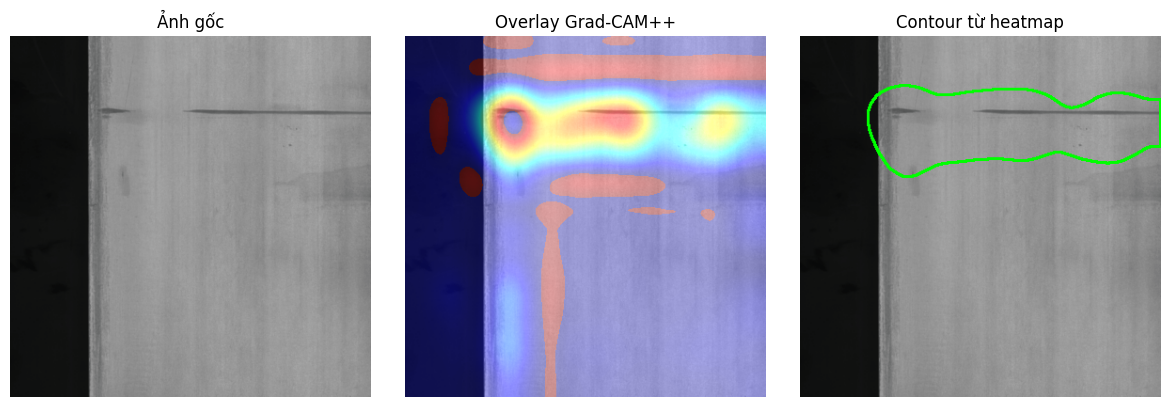

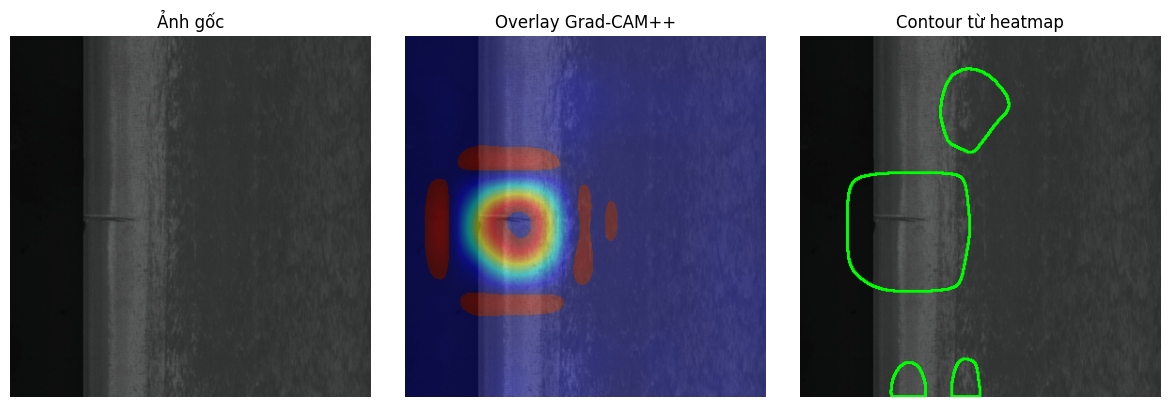

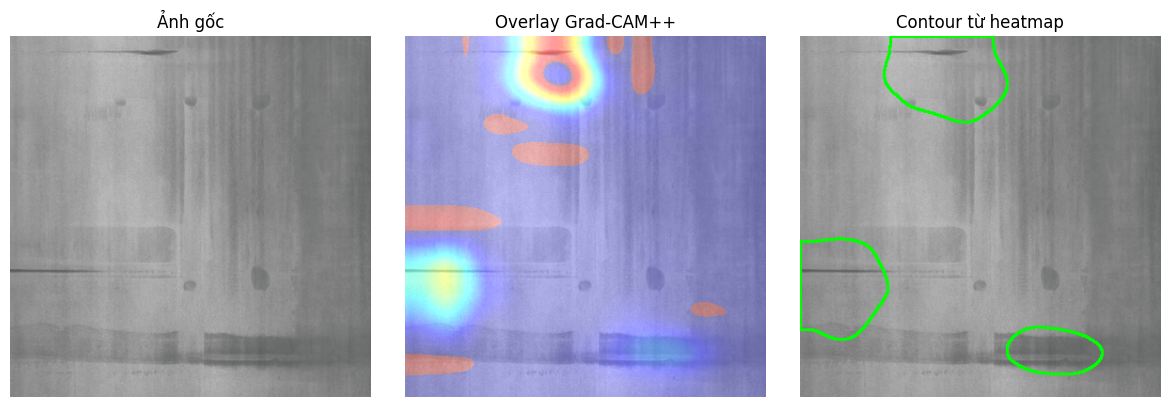

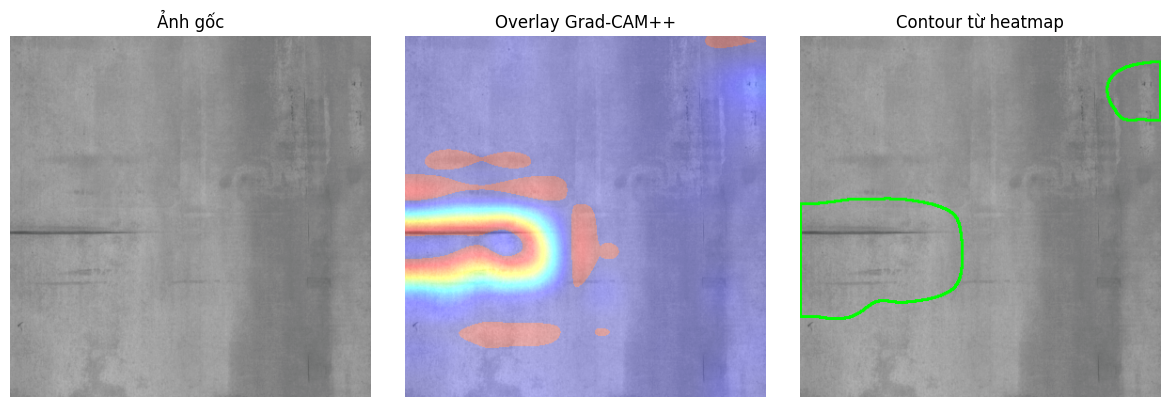

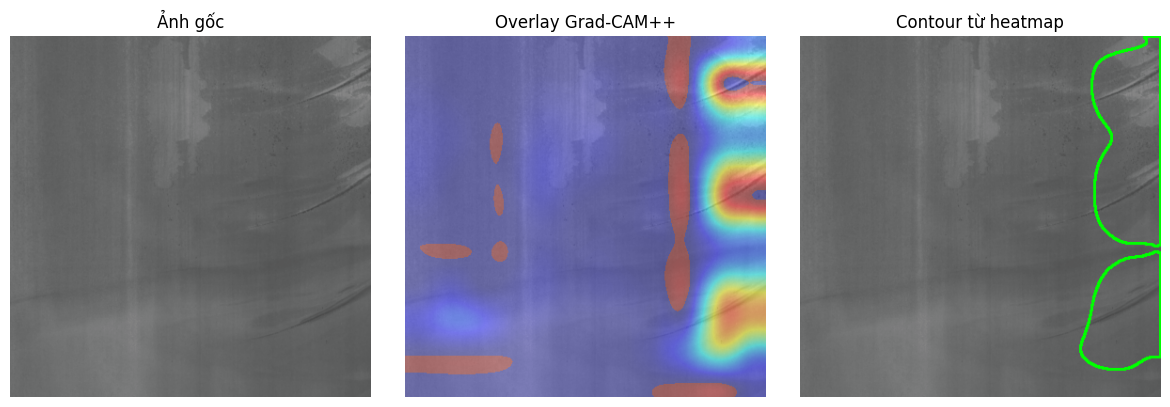

In [16]:
# Minh hoạ trên vài ảnh TEST bất kỳ
from PIL import Image
from torchvision import transforms as T

to_tensor = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor(), T.Normalize(mean,std)])

def visualize_one(img_path, percentile=85):
    img = Image.open(img_path).convert("RGB")
    x = to_tensor(img).unsqueeze(0).to(DEVICE)
    campp = CamPlusPlus(model, "layer4")
    hm = campp(x)
    campp.remove()

    img_rgb = denorm(x[0])
    hm_resz = cv2.resize(hm, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)
    overlay = cv2.addWeighted(img_rgb, 1.0,
                              cv2.applyColorMap((hm_resz*255).astype(np.uint8), cv2.COLORMAP_JET)[:,:,::-1],
                              0.45, 0)

    mask = heatmap_to_mask(hm_resz, percentile=percentile, min_area=80)
    vis = img_rgb.copy()
    cnts,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis, cnts, -1, (0,255,0), 2)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title("Ảnh gốc"); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(overlay); plt.title("Overlay Grad-CAM++"); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(vis); plt.title("Contour từ heatmap"); plt.axis('off')
    plt.tight_layout(); plt.show()

# ví dụ: hiển thị 5 ảnh đầu của một lớp trong test
sample_dir = os.path.join(DATA_ROOT, "test", list(train_ds.class_to_idx.keys())[0])
samples = [os.path.join(sample_dir, f) for f in os.listdir(sample_dir) if f.lower().endswith((".jpg",".png",".jpeg"))][:5]
for p in samples:
    visualize_one(p, percentile=85)